In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import joblib


In [2]:
rfm_features = pd.read_csv("../data/rfm_features.csv")
rfm_raw = pd.read_csv("../data/rfm_raw.csv")

rfm_features.head()


,Recency,Frequency,Monetary,CustomerID
0,1.462236,-0.955013,3.696168,12346.0
1,-2.038611,1.074523,1.408758,12347.0
2,0.373310,0.386437,0.715517,12348.0
3,-0.622914,-0.955013,0.697821,12349.0
4,1.424800,-0.955013,-0.615877,12350.0


In [3]:
X = rfm_features[["Recency", "Frequency", "Monetary"]]


In [4]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)


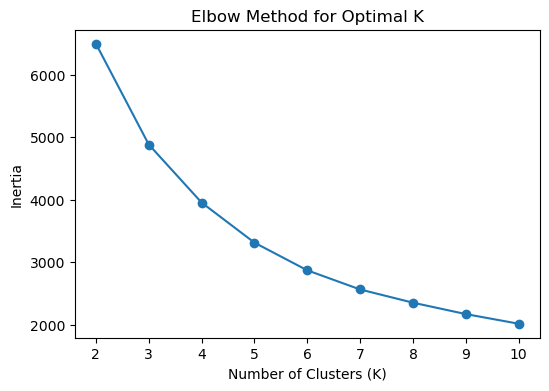

In [5]:
plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


In [6]:
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")


K=2, Silhouette Score=0.433
K=3, Silhouette Score=0.339
K=4, Silhouette Score=0.336
K=5, Silhouette Score=0.316
K=6, Silhouette Score=0.313


In [7]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_features["Cluster"] = kmeans.fit_predict(X)

rfm_features.head()


,Recency,Frequency,Monetary,CustomerID,Cluster
0,1.462236,-0.955013,3.696168,12346.0,2
1,-2.038611,1.074523,1.408758,12347.0,1
2,0.373310,0.386437,0.715517,12348.0,2
3,-0.622914,-0.955013,0.697821,12349.0,0
4,1.424800,-0.955013,-0.615877,12350.0,3


In [9]:
rfm_segmented = rfm_raw.merge(
    rfm_features[["CustomerID", "Cluster"]],
    on="CustomerID",
    how="left"
)

rfm_segmented.head()


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,2
1,12347.0,2,7,4310.00,1
2,12348.0,75,4,1797.24,2
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,3


In [10]:
cluster_profile = rfm_segmented.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": ["mean", "count"]
}).round(2)

cluster_profile


Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0         18.73      2.09   538.23   839
1         12.11     13.63  8015.42   723
2         70.70      4.08  1791.09  1183
3        184.02      1.32   342.42  1594

In [11]:
cluster_labels = {
    0: "Loyal High-Value",
    1: "At-Risk Customers",
    2: "New Customers",
    3: "Low-Value Customers"
}

rfm_segmented["Segment"] = rfm_segmented["Cluster"].map(cluster_labels)
rfm_segmented.head()


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,2,New Customers
1,12347.0,2,7,4310.00,1,At-Risk Customers
2,12348.0,75,4,1797.24,2,New Customers
3,12349.0,19,1,1757.55,0,Loyal High-Value
4,12350.0,310,1,334.40,3,Low-Value Customers


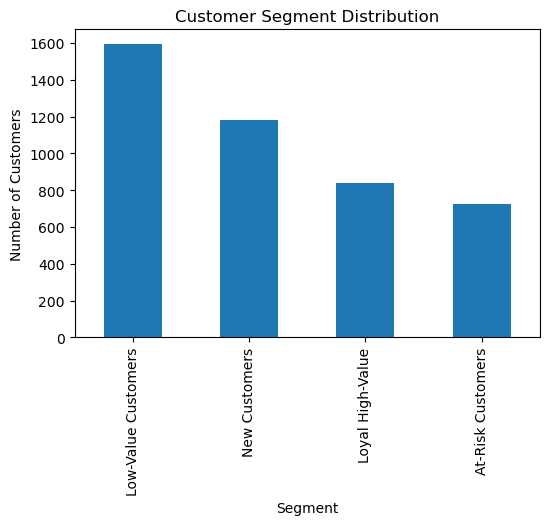

In [12]:
plt.figure(figsize=(6,4))
rfm_segmented["Segment"].value_counts().plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.ylabel("Number of Customers")
plt.show()


In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

rfm_features["PCA1"] = X_pca[:, 0]
rfm_features["PCA2"] = X_pca[:, 1]


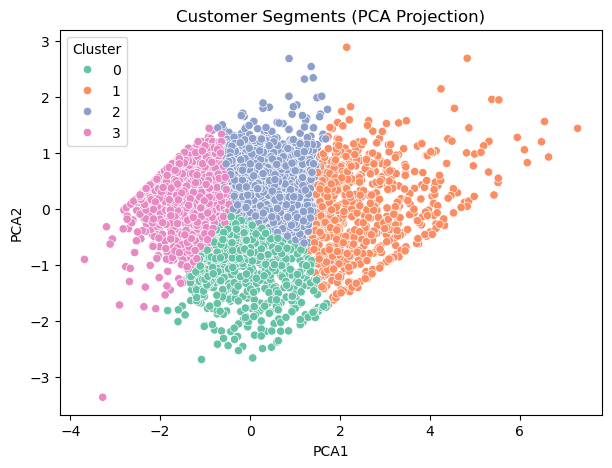

In [14]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    data=rfm_features,
    palette="Set2"
)
plt.title("Customer Segments (PCA Projection)")
plt.show()


In [15]:
rfm_segmented.to_csv("../data/customer_segments.csv", index=False)

joblib.dump(kmeans, "../models/kmeans_model.pkl")
joblib.dump(pca, "../models/pca_model.pkl")

print("✅ Customer segmentation files saved")


✅ Customer segmentation files saved
